# FNN网络拟合一元函数

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import time
import scipy.io as io
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on: %s'%(device))


running on: cuda


## 构建FNN网络

In [2]:
## ----构建FNN网络----
class FNN(nn.Module):
    def __init__(self, layers, actn = 'tanh'):
        super().__init__()
        L = len(layers)


        self.linear = nn.ModuleList([nn.Linear(layers[l-1], layers[l]) for l in range(1, L)])

        # 激活函数
        if actn == 'relu':
            actn = nn.ReLU()
        elif actn == 'tanh':
            actn = nn.Tanh()
        elif actn == 'sigmoid':
            actn = nn.Sigmoid()
        self.activation = actn

    def forward(self, inputs):
        x = inputs
        for linear in self.linear[:-1]:
            x = self.activation(linear(x))
        x = self.linear[-1](x)
        return x


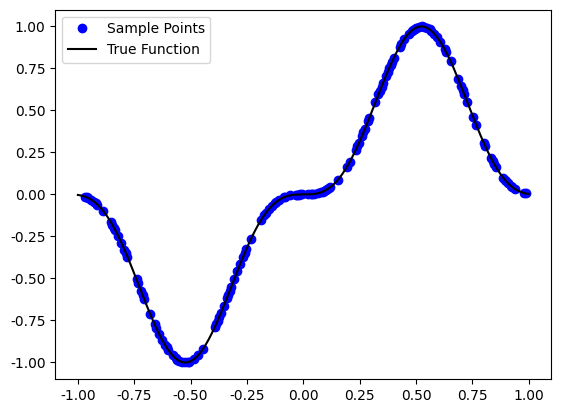

In [3]:


# 目标函数
def target_func(x):
    return np.sin(3*x)**3 

# 生成数据
def generate_data(num_train=150): # 样本点数
    num_test = 301 # 全集与样本点数
    x = np.linspace(-1, 1, num_test).reshape((-1, 1))
    y = target_func(x)
    idx = np.random.choice(num_test, num_train,  replace=False)

    #训练点数
    x_train, y_train = x[idx], y[idx]
    return x_train, y_train, x, y

# 训练点数
num_train = 150
# 数据集
x_train, y_train, x_ref, y_ref = generate_data(num_train)

plt.figure()
matplotlib.rcParams['axes.unicode_minus'] =False
# plt.rcParams['font.sans-serif']=['KaiTi'] 
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')
plt.legend()
plt.show()

## 模型训练

In [4]:
## ----模型训练---

# 训练模型
def train_model(x_train, y_train, layers=[1, 50, 50, 1], actn='tanh', epochs=10000):
    # 网络模型
    model = FNN(layers, actn)
    model = model.to(device)
    print(model.state_dict()['linear.2.weight'].shape)

    x_train, y_train = torch.tensor(x_train, dtype=torch.float32), \
        torch.tensor(y_train, dtype=torch.float32)
    x_train, y_train = x_train.to(device), y_train.to(device)


    opt = torch.optim.Adam(model.parameters(), lr=1.0e-3)
    loss_fn = nn.MSELoss()

    loss_history = []

    for epoch in range(1,epochs+1):
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        opt.zero_grad() #梯度清零
        loss.backward()
        opt.step()
        loss_history.append(loss.item())


        if epoch%1000 == 0:
            print('Steps: %d, loss: %.3e'%(epoch, loss.item()))
    loss_history = np.array(loss_history).reshape(-1,1)
    return model.cpu(),loss_history

#  网络结构层数与深度
layers = [1] + [100]*3 + [1]
# 激活函数
actn = 'tanh'
# 训练轮次
epochs = 5000


model, loss = train_model(x_train, y_train, layers, actn, epochs)



torch.Size([100, 100])
Steps: 1000, loss: 3.824e-05
Steps: 2000, loss: 4.765e-05
Steps: 3000, loss: 1.543e-05
Steps: 4000, loss: 1.199e-05
Steps: 5000, loss: 1.451e-05


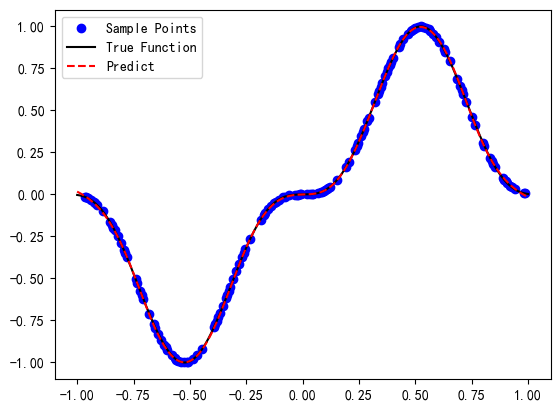

In [5]:
x_ref = torch.tensor(x_ref, dtype=torch.float32)
y_test = model(x_ref)

plt.figure()
plt.rcParams['font.sans-serif']=['KaiTi'] 
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')

plt.plot(x_ref, y_test.detach().numpy(), 'r--',label="Predict")
plt.legend()
plt.show()

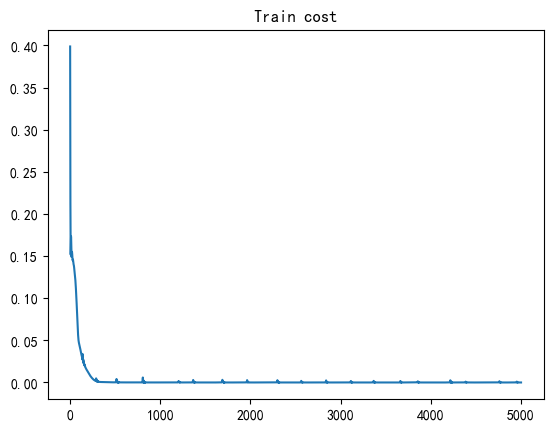

In [6]:
nsum = np.array([i+1 for i in range(epochs)]).reshape(-1,1)

plt.figure()
plt.plot(nsum, loss ,label="Train cost")
plt.title('Train cost')
plt.show()

In [7]:
## 模型评估

def evaluate(model):

    x_test=np.linspace(-1,1,301).reshape((-1,1))
    y_true=target_func(x_test)

    x_test_tensor=torch.tensor(x_test, dtype=torch.float32)

    with torch.no_grad():
        y_pred=model.cpu()(x_test_tensor)

    mse=mean_squared_error(y_true,y_pred)
    mae=mean_absolute_error(y_true,y_pred)

    return x_test, y_true, y_pred, mse, mae
 
test = evaluate(model)
print(dict(zip(['MSE','MAE'],test[3:])))

{'MSE': 1.785643476909823e-05, 'MAE': 0.0031040491143614615}


In [8]:
def plot_result(x_true,y_true,y_pred,title):
    plt.figure(figsize=(6,4))
    plt.plot(x_true,y_true,label="True Function")
    plt.plot(x_true,y_pred,label="Prediction")
    plt.legend()
    plt.title(title)
    plt.show()


def plot_loss(loss_dict, title):
    plt.figure()
    for key, loss in loss_dict.items():
        plt.plot(loss, label=key)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()


## 问题1：训练点数影响

torch.Size([1, 50])
Steps: 1000, loss: 4.482e-05
Steps: 2000, loss: 2.728e-07
Steps: 3000, loss: 1.882e-07
Steps: 4000, loss: 1.306e-07
Steps: 5000, loss: 1.997e-05
Steps: 6000, loss: 3.821e-06
Steps: 7000, loss: 5.020e-08
Steps: 8000, loss: 1.747e-05
Steps: 9000, loss: 7.308e-08
Steps: 10000, loss: 1.706e-08


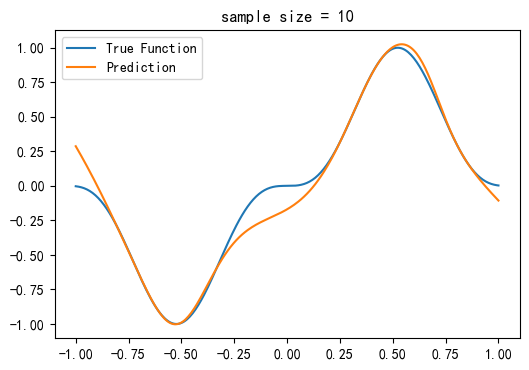

torch.Size([1, 50])
Steps: 1000, loss: 3.104e-04
Steps: 2000, loss: 5.651e-05
Steps: 3000, loss: 1.203e-05
Steps: 4000, loss: 5.580e-06
Steps: 5000, loss: 1.348e-05
Steps: 6000, loss: 3.808e-06
Steps: 7000, loss: 3.152e-06
Steps: 8000, loss: 3.033e-06
Steps: 9000, loss: 2.032e-06
Steps: 10000, loss: 1.570e-06


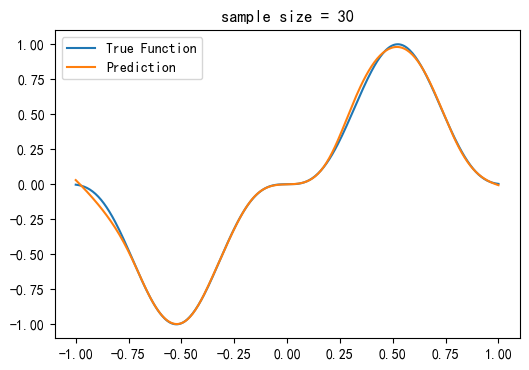

torch.Size([1, 50])
Steps: 1000, loss: 6.668e-04
Steps: 2000, loss: 2.201e-04
Steps: 3000, loss: 7.034e-05
Steps: 4000, loss: 2.616e-05
Steps: 5000, loss: 1.085e-05
Steps: 6000, loss: 7.340e-06
Steps: 7000, loss: 5.790e-06
Steps: 8000, loss: 4.736e-06
Steps: 9000, loss: 4.615e-06
Steps: 10000, loss: 3.254e-06


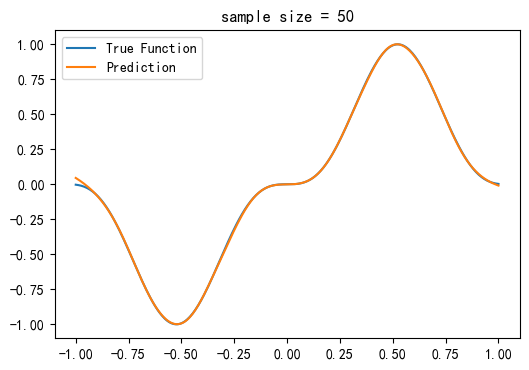

torch.Size([1, 50])
Steps: 1000, loss: 1.871e-04
Steps: 2000, loss: 4.004e-05
Steps: 3000, loss: 1.728e-05
Steps: 4000, loss: 8.189e-06
Steps: 5000, loss: 5.311e-06
Steps: 6000, loss: 3.919e-06
Steps: 7000, loss: 2.978e-06
Steps: 8000, loss: 2.240e-06
Steps: 9000, loss: 2.919e-06
Steps: 10000, loss: 1.416e-06


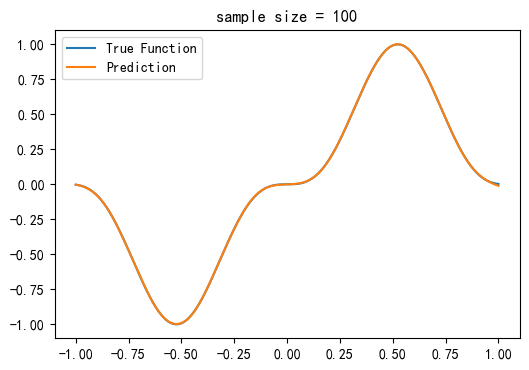

torch.Size([1, 50])
Steps: 1000, loss: 1.001e-03
Steps: 2000, loss: 1.681e-04
Steps: 3000, loss: 6.942e-05
Steps: 4000, loss: 3.066e-05
Steps: 5000, loss: 1.461e-05
Steps: 6000, loss: 1.137e-05
Steps: 7000, loss: 9.277e-06
Steps: 8000, loss: 7.396e-06
Steps: 9000, loss: 6.206e-06
Steps: 10000, loss: 4.261e-06


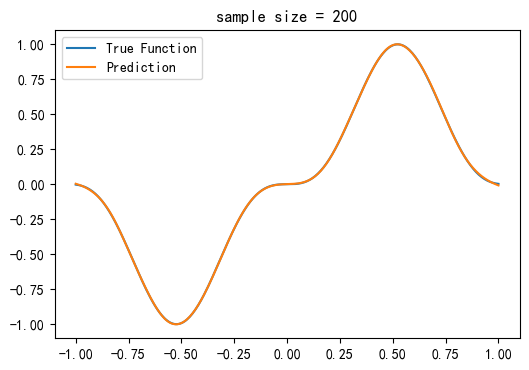

[[1.00000000e+01 7.82508003e-03 5.38074143e-02]
 [3.00000000e+01 4.30416569e-04 1.16559819e-02]
 [5.00000000e+01 4.26783400e-05 3.28604901e-03]
 [1.00000000e+02 3.31146701e-06 1.25810350e-03]
 [2.00000000e+02 5.04196072e-06 1.72843225e-03]]


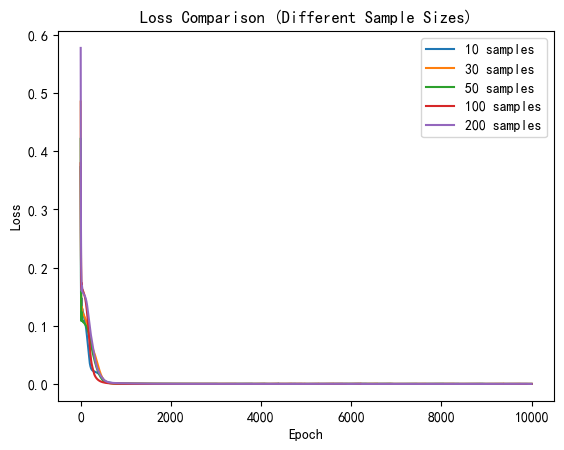

In [9]:
## ----训练点数影响----
sample_sizes = [10, 30, 50, 100, 200]

results_q1 = []
loss_dict_q1 = {}

for n in sample_sizes:
    x_train_q1, y_train_q1, x_ref_q1, y_ref_q1 = generate_data(n)
    model_q1 ,loss_q1= train_model(x_train_q1, y_train_q1)

    x_test_q1, y_true_q1, y_pred_q1, mse_q1, mae_q1 = evaluate(model_q1)
    results_q1.append([n, mse_q1, mae_q1])

    loss_dict_q1[str(n)+' samples']=loss_q1
    
    plot_result(x_test_q1, y_true_q1, y_pred_q1,f"sample size = {n}")
print(np.array(results_q1))

plot_loss(loss_dict_q1, title='Loss Comparison (Different Sample Sizes)')

## 问题2：网络结构（层数与深度）影响

[1, 20, 20, 1]
torch.Size([1, 20])
Steps: 1000, loss: 5.615e-04
Steps: 2000, loss: 2.869e-04
Steps: 3000, loss: 1.221e-04
Steps: 4000, loss: 4.108e-05
Steps: 5000, loss: 2.026e-05
Steps: 6000, loss: 1.104e-05
Steps: 7000, loss: 6.604e-06
Steps: 8000, loss: 4.190e-06
Steps: 9000, loss: 2.812e-06
Steps: 10000, loss: 2.361e-06
structure: [20, 20] MSE: 2.9723541806773497e-06 MAE: 0.0013506339639033807


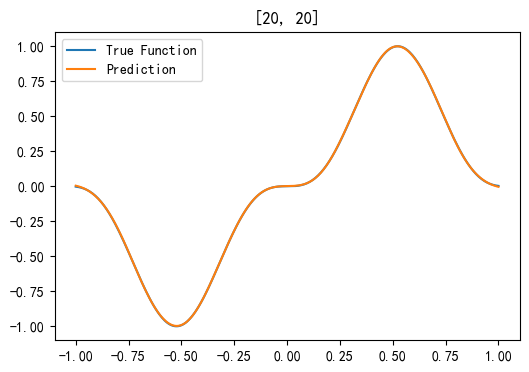

[1, 20, 20, 20, 1]
torch.Size([20, 20])
Steps: 1000, loss: 3.257e-04
Steps: 2000, loss: 9.214e-05
Steps: 3000, loss: 2.526e-05
Steps: 4000, loss: 1.472e-05
Steps: 5000, loss: 1.302e-05
Steps: 6000, loss: 9.631e-06
Steps: 7000, loss: 2.080e-05
Steps: 8000, loss: 7.622e-06
Steps: 9000, loss: 6.994e-06
Steps: 10000, loss: 6.705e-06
structure: [20, 20, 20] MSE: 6.234975744894427e-06 MAE: 0.0020139104640418894


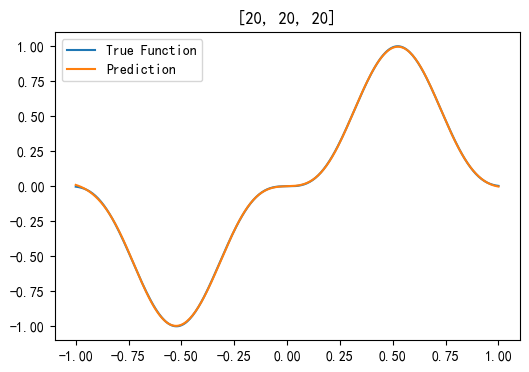

[1, 50, 50, 1]
torch.Size([1, 50])
Steps: 1000, loss: 2.576e-04
Steps: 2000, loss: 6.761e-05
Steps: 3000, loss: 1.966e-05
Steps: 4000, loss: 1.193e-05
Steps: 5000, loss: 6.976e-06
Steps: 6000, loss: 6.674e-06
Steps: 7000, loss: 8.777e-06
Steps: 8000, loss: 1.768e-06
Steps: 9000, loss: 1.468e-06
Steps: 10000, loss: 8.219e-06
structure: [50, 50] MSE: 1.4754113847512047e-05 MAE: 0.003579101876090043


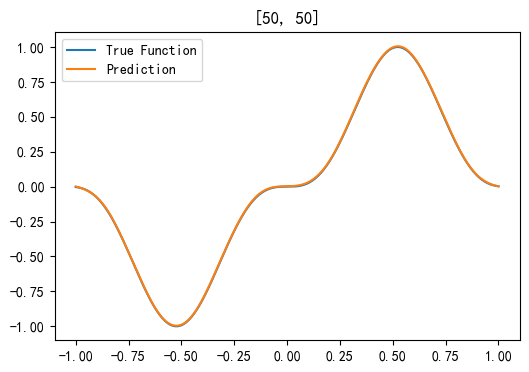

[1, 50, 50, 50, 1]
torch.Size([50, 50])
Steps: 1000, loss: 6.452e-05
Steps: 2000, loss: 1.468e-04
Steps: 3000, loss: 1.247e-05
Steps: 4000, loss: 7.984e-06
Steps: 5000, loss: 5.411e-06
Steps: 6000, loss: 4.070e-06
Steps: 7000, loss: 2.475e-05
Steps: 8000, loss: 3.522e-06
Steps: 9000, loss: 2.665e-05
Steps: 10000, loss: 1.851e-06
structure: [50, 50, 50] MSE: 1.7970939599670007e-06 MAE: 0.001006423521439831


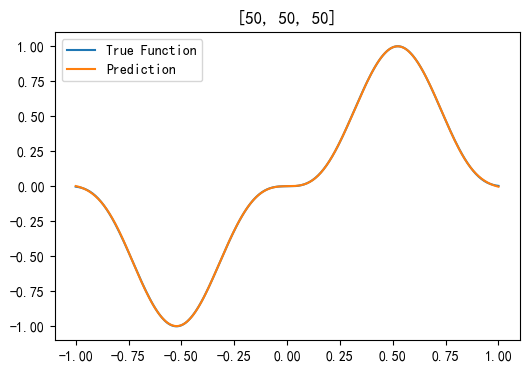

[1, 50, 50, 50, 50, 1]
torch.Size([50, 50])
Steps: 1000, loss: 3.597e-05
Steps: 2000, loss: 1.222e-04
Steps: 3000, loss: 1.693e-05
Steps: 4000, loss: 1.556e-05
Steps: 5000, loss: 1.464e-05
Steps: 6000, loss: 1.365e-05
Steps: 7000, loss: 1.280e-05
Steps: 8000, loss: 1.144e-05
Steps: 9000, loss: 9.447e-06
Steps: 10000, loss: 8.708e-06
structure: [50, 50, 50, 50] MSE: 1.2809459084420765e-05 MAE: 0.0025894966318121505


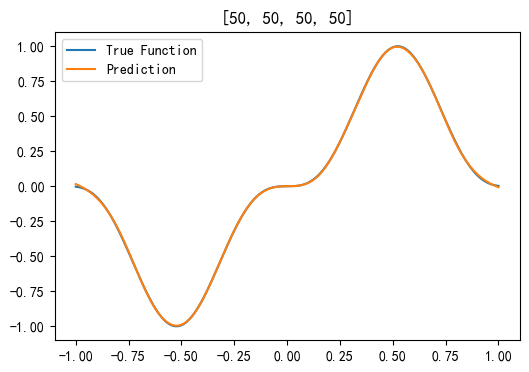

[1, 100, 100, 1]
torch.Size([1, 100])
Steps: 1000, loss: 8.643e-05
Steps: 2000, loss: 2.764e-05
Steps: 3000, loss: 1.053e-05
Steps: 4000, loss: 5.881e-06
Steps: 5000, loss: 3.577e-06
Steps: 6000, loss: 2.657e-06
Steps: 7000, loss: 1.056e-05
Steps: 8000, loss: 1.626e-06
Steps: 9000, loss: 1.328e-06
Steps: 10000, loss: 1.053e-06
structure: [100, 100] MSE: 1.2378979453378053e-06 MAE: 0.0009269256815487219


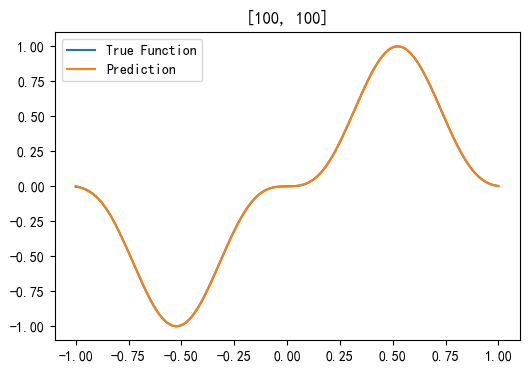

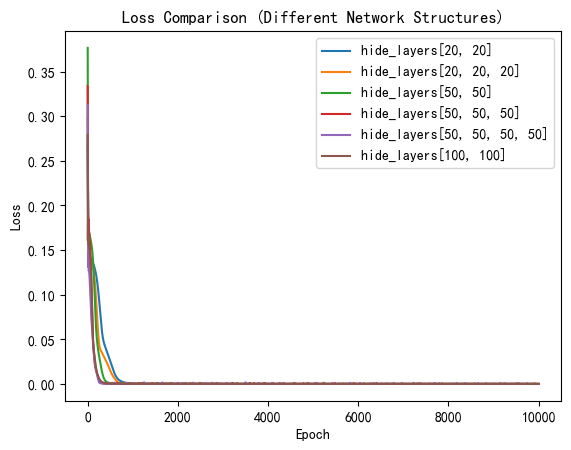

In [10]:
## ----网络结构影响----
hide_layers = [[20,20], [20,20,20], [50,50], [50,50,50],[50,50,50,50],[100,100]]
loss_dict_q2 = {}

for s in hide_layers:
    layers_q2 = [1] + s +[1]
    print(layers_q2)

    x_train_q2, y_train_q2, x_ref_q2, y_ref_q2 = generate_data()
    model_q2, loss_q2= train_model(x_train_q2, y_train_q2, layers=layers_q2)

    loss_dict_q2['hide_layers'+str(s)]=loss_q2
    x_test_q2, y_true_q2, y_pred_q2, mse_q2, mae_q2 = evaluate(model_q2)
    print('structure:', s, "MSE:", mse_q2, "MAE:", mae_q2)
    plot_result(x_test_q2, y_true_q2, y_pred_q2, str(s))

plot_loss(loss_dict_q2, title='Loss Comparison (Different Network Structures)')


## 问题3：激活函数影响

torch.Size([1, 50])
Steps: 1000, loss: 3.111e-04
Steps: 2000, loss: 9.117e-05
Steps: 3000, loss: 4.834e-05
Steps: 4000, loss: 2.377e-05
Steps: 5000, loss: 1.325e-05
Steps: 6000, loss: 1.029e-05
Steps: 7000, loss: 8.769e-06
Steps: 8000, loss: 7.987e-06
Steps: 9000, loss: 7.487e-06
Steps: 10000, loss: 7.171e-06
structure: [100, 100] MSE: 1.1929293713475832e-05 MAE: 0.0023456830405065633


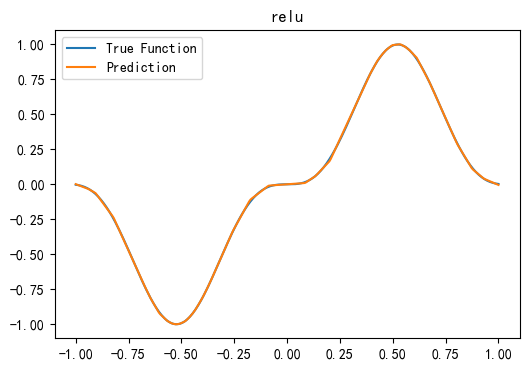

torch.Size([1, 50])
Steps: 1000, loss: 7.499e-04
Steps: 2000, loss: 8.629e-05
Steps: 3000, loss: 4.496e-05
Steps: 4000, loss: 2.589e-05
Steps: 5000, loss: 2.058e-05
Steps: 6000, loss: 7.245e-05
Steps: 7000, loss: 9.741e-06
Steps: 8000, loss: 7.213e-06
Steps: 9000, loss: 2.095e-05
Steps: 10000, loss: 4.225e-06
structure: [100, 100] MSE: 5.112154970658126e-06 MAE: 0.0015582499102904182


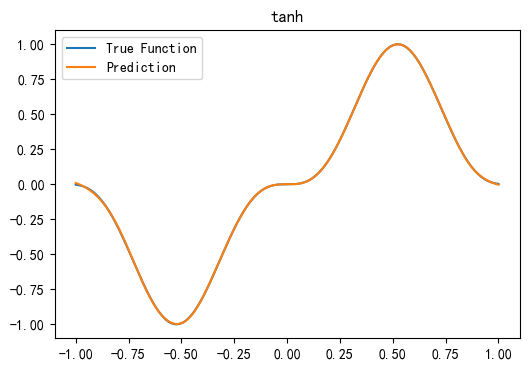

torch.Size([1, 50])
Steps: 1000, loss: 1.006e-01
Steps: 2000, loss: 3.315e-03
Steps: 3000, loss: 5.154e-04
Steps: 4000, loss: 1.542e-04
Steps: 5000, loss: 7.778e-05
Steps: 6000, loss: 6.261e-05
Steps: 7000, loss: 5.509e-05
Steps: 8000, loss: 8.055e-05
Steps: 9000, loss: 4.518e-05
Steps: 10000, loss: 4.106e-05
structure: [100, 100] MSE: 4.459697167431503e-05 MAE: 0.005717105368081242


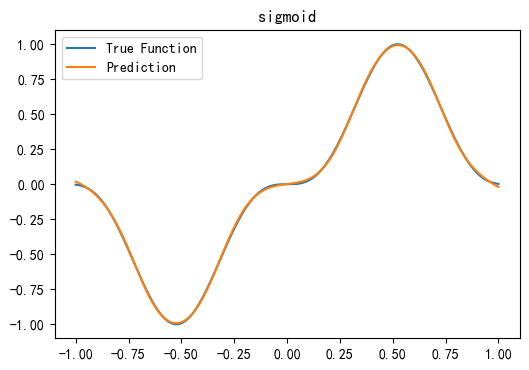

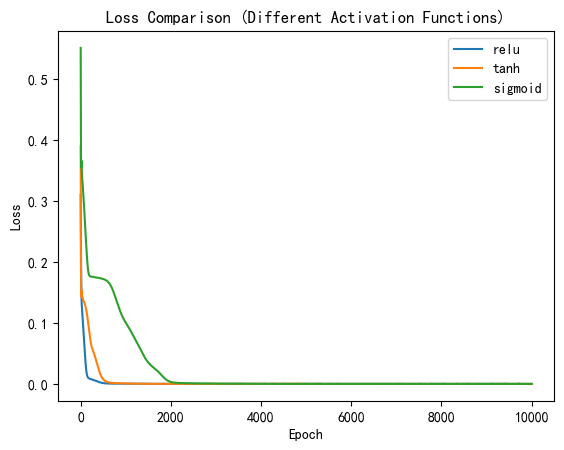

In [11]:
## ----激活函数影响----
activations = ['relu', 'tanh', 'sigmoid']
loss_dict_q3 = {}

for act in activations:
    x_train_q3, y_train_q3, x_ref_q3, y_ref_q3 = generate_data()
    model_q3, loss_q3= train_model(x_train_q3, y_train_q3, actn = act)

    loss_dict_q3[act]=loss_q3
    x_test_q3, y_true_q3, y_pred_q3, mse_q3, mae_q3 = evaluate(model_q3)
    print('structure:', s, "MSE:", mse_q3, "MAE:", mae_q3)
    plot_result(x_test_q3, y_true_q3, y_pred_q3, act)


plot_loss(loss_dict_q3, title='Loss Comparison (Different Activation Functions)')